# Tutorial 3: Model Optimization

**Sickle Cell Disease Classification — Training Configuration**

This tutorial covers:
1. Loss function specification
2. Optimization algorithm selection
3. Learning rate configuration
4. Batch size determination
5. Epoch settings
6. Analysis of training vs validation loss patterns

In [48]:
# Install necessary libraries
!pip install -q ultralytics torch torchvision opencv-python-headless matplotlib seaborn scikit-learn pandas numpy albumentations timm kaggle tqdm pyyaml Pillow grad-cam

In [49]:
# Download the dataset from Kaggle and unzip it
!kaggle datasets download -d florencetushabe/sickle-cell-disease-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/florencetushabe/sickle-cell-disease-dataset
License(s): DbCL-1.0
100% 253M/253M [00:10<00:00, 25.2MB/s] 



In [50]:
import os, shutil, random, yaml, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (f1_score, roc_auc_score, roc_curve,
                             precision_score, recall_score, confusion_matrix)
from ultralytics import YOLO
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

## Setup Prepare Dataset (from Tutorial 1)

In [51]:
DATA_DIR = "."
os.makedirs("outputs", exist_ok=True)

LABELLED_DIR = os.path.join(DATA_DIR, "Positive", "Labelled")
RAW_DIR      = os.path.join(DATA_DIR, "Positive", "Unlabelled")
CLEAR_DIR    = os.path.join(DATA_DIR, "Negative", "Clear")

# --- Extract YOLO labels by comparing labelled vs unlabelled images ---
LABELS_OUT = "data/processed/labels"
os.makedirs(LABELS_OUT, exist_ok=True)

for f in sorted(os.listdir(LABELLED_DIR)):
    if not f.lower().endswith(('.jpg','.png','.jpeg')):
        continue
    lab_p, raw_p = os.path.join(LABELLED_DIR, f), os.path.join(RAW_DIR, f)
    if not os.path.exists(raw_p):
        continue
    lab, raw = cv2.imread(lab_p), cv2.imread(raw_p)
    if lab is None or raw is None:
        continue
    h, w = lab.shape[:2]
    diff = cv2.absdiff(lab, cv2.resize(raw, (w, h)))
    th = cv2.morphologyEx(
        cv2.threshold(cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY), 40, 255, cv2.THRESH_BINARY)[1],
        cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)), 2)
    boxes = []
    for c in cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]:
        x,y,bw,bh = cv2.boundingRect(c)
        if not (400 < bw*bh < 0.1*w*h): continue
        if max(bw,bh)/(min(bw,bh)+1e-6) > 4: continue
        if not (4 <= len(cv2.approxPolyDP(c, 0.04*cv2.arcLength(c,True), True)) <= 12): continue
        boxes.append([1,(x+bw/2)/w,(y+bh/2)/h,bw/w,bh/h])
    if not boxes:
        continue
    out = os.path.join(LABELS_OUT, f.replace(".jpg",".txt").replace(".png",".txt"))
    with open(out, "w") as fp:
        fp.write("\n".join(f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}" for c,x,y,w,h in boxes))

# --- Create train / val / test splits ---
YOLO_ROOT = "data/yolo_dataset"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(YOLO_ROOT, "images", split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_ROOT, "labels", split), exist_ok=True)

pos_labelled_files = sorted([f for f in os.listdir(LABELLED_DIR)
    if f.lower().endswith(('.jpg','.jpeg','.png'))
    and os.path.exists(os.path.join(LABELS_OUT, os.path.splitext(f)[0]+".txt"))])

pos_train, pos_temp = train_test_split(pos_labelled_files, test_size=0.4, random_state=42)
pos_val, pos_test   = train_test_split(pos_temp, test_size=0.5, random_state=42)

for split_name, split_files in [("train",pos_train),("val",pos_val),("test",pos_test)]:
    for fname in split_files:
        s = os.path.join(RAW_DIR, fname)
        if not os.path.exists(s): s = os.path.join(LABELLED_DIR, fname)
        shutil.copy2(s, os.path.join(YOLO_ROOT,"images",split_name,fname))
        lbl = os.path.splitext(fname)[0]+".txt"
        shutil.copy2(os.path.join(LABELS_OUT,lbl), os.path.join(YOLO_ROOT,"labels",split_name,lbl))

neg_files = sorted([f for f in os.listdir(CLEAR_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))])
neg_train, neg_temp = train_test_split(neg_files, test_size=0.4, random_state=42)
neg_val, neg_test   = train_test_split(neg_temp, test_size=0.5, random_state=42)

for split_name, split_files in [("train",neg_train),("val",neg_val),("test",neg_test)]:
    for fname in split_files:
        shutil.copy2(os.path.join(CLEAR_DIR,fname), os.path.join(YOLO_ROOT,"images",split_name,f"neg_{fname}"))
        lbl = f"neg_{os.path.splitext(fname)[0]}.txt"
        with open(os.path.join(YOLO_ROOT,"labels",split_name,lbl),"w") as f:
            f.write("0 0.500000 0.500000 1.000000 1.000000\n")

yaml_path = os.path.join(YOLO_ROOT, "dataset.yaml")
config = {"path":os.path.abspath(YOLO_ROOT),"train":"images/train","val":"images/val",
          "test":"images/test","nc":2,"names":["normal","sickle"]}
with open(yaml_path,"w") as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print(f"Dataset ready: {len(pos_train)+len(neg_train)} train | "
      f"{len(pos_val)+len(neg_val)} val | {len(pos_test)+len(neg_test)} test")

Dataset ready: 339 train | 113 val | 114 test


## 1. Loss Functions

Each model uses a different loss formulation matched to its task:

| Model | Loss Components | Purpose |
|-------|----------------|---------|
| **YOLOv8 / YOLO12** | CIoU (box) + BCE (class) + DFL | Bounding-box regression + classification |
| **SW-ViT** | CrossEntropyLoss | 2-class image classification |

- **CIoU** (Complete IoU) penalises box offset, aspect-ratio mismatch, and overlap simultaneously.
- **DFL** (Distribution Focal Loss) models the box boundary as a distribution for finer localisation.
- **BCE** (Binary Cross-Entropy) scores each class independently per anchor.
- **CrossEntropyLoss** combines log-softmax and NLL — standard for multi-class classification.

In [52]:
import torch.nn as nn

# SW-ViT loss
criterion = nn.CrossEntropyLoss()
dummy_logits = torch.tensor([[2.0, 0.5], [0.3, 1.8]])
dummy_labels = torch.tensor([0, 1])
loss = criterion(dummy_logits, dummy_labels)
print(f"CrossEntropyLoss example: {loss.item():.4f}")

# YOLO losses are computed internally by Ultralytics
print("\nYOLO loss components (computed internally during training):")
print("  box_loss  : CIoU loss for bounding-box regression")
print("  cls_loss  : Binary cross-entropy for class prediction")
print("  dfl_loss  : Distribution focal loss for box refinement")

CrossEntropyLoss example: 0.2014

YOLO loss components (computed internally during training):
  box_loss  : CIoU loss for bounding-box regression
  cls_loss  : Binary cross-entropy for class prediction
  dfl_loss  : Distribution focal loss for box refinement


## 2. Optimization Algorithm

All three models use **AdamW** — Adam with decoupled weight decay, which prevents the regularisation term from interfering with the adaptive learning rate.

| Hyperparameter | YOLOv8 / YOLO12 | SW-ViT |
|---------------|-----------------|--------|
| Optimizer | AdamW | AdamW |
| Weight decay | 0.0005 | 0.01 |
| Betas | (0.9, 0.999) | (0.9, 0.999) |

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SW-ViT optimiser setup
model_swvit = timm.create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=2).to(device)

optimizer = torch.optim.AdamW(
    model_swvit.parameters(),
    lr=1e-4,
    weight_decay=1e-2
)

print("AdamW Optimizer Configuration (SW-ViT)")
print("=" * 50)
for group in optimizer.param_groups:
    print(f"  lr           : {group['lr']}")
    print(f"  weight_decay : {group['weight_decay']}")
    print(f"  betas        : {group['betas']}")
    print(f"  # parameters : {len(group['params'])}")

AdamW Optimizer Configuration (SW-ViT)
  lr           : 0.0001
  weight_decay : 0.01
  betas        : (0.9, 0.999)
  # parameters : 329


## 3. Learning Rate Configuration

| Model | Initial LR | Final LR | Schedule | Warmup |
|-------|-----------|----------|----------|--------|
| YOLOv8 / YOLO12 | 0.001 | 0.00001 | Cosine decay | 3 epochs |
| SW-ViT | 0.0001 | ~0 | CosineAnnealingLR | None |

/tmp/ipykernel_854/2045258849.py:6: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


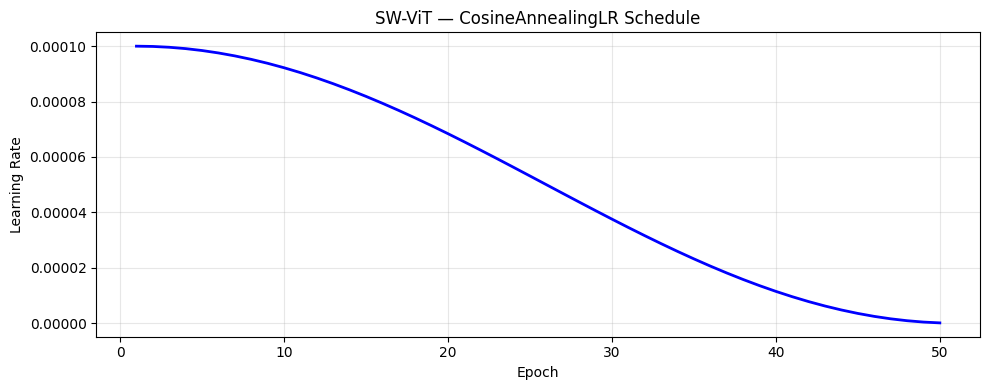

LR at epoch  1: 0.000100
LR at epoch 25: 0.000053
LR at epoch 50: 0.000000


In [54]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

lrs = []
for epoch in range(50):
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, 51), lrs, 'b-', lw=2)
ax.set(xlabel="Epoch", ylabel="Learning Rate", title="SW-ViT — CosineAnnealingLR Schedule")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"LR at epoch  1: {lrs[0]:.6f}")
print(f"LR at epoch 25: {lrs[24]:.6f}")
print(f"LR at epoch 50: {lrs[49]:.6f}")

## 4. Batch Size & Epoch Settings

| Model | Batch Size | Max Epochs | Early Stopping (patience) | Image Size |
|-------|-----------|-----------|--------------------------|-----------|
| YOLOv8 | 16 | 50 | 50 | 640 × 640 |
| YOLO12 | 16 | 50 | 50 | 640 × 640 |
| SW-ViT | 32 | 50 | — (best F1 checkpoint) | 224 × 224 |

**Batch size rationale:**
- YOLO: batch 16 balances GPU memory usage on a Tesla T4 (16 GB) with 640² images.
- SW-ViT: batch 32 is feasible because 224² images are much smaller in memory.

## 5. Training vs Validation Loss Analysis

We train the SW-ViT model for a few epochs to demonstrate the train/val loss pattern. (Full training is covered in Tutorial 6.)

In [55]:
class SickleCellDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.samples = []
        for f in sorted(os.listdir(img_dir)):
            if not f.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            label = 0 if f.startswith("neg_") else 1
            self.samples.append((os.path.join(img_dir, f), label))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, label

swin_train_tf = A.Compose([
    A.Resize(224, 224, interpolation=cv2.INTER_CUBIC),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.3),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2(),
])
swin_val_tf = A.Compose([
    A.Resize(224, 224, interpolation=cv2.INTER_CUBIC),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2(),
])

YOLO_ROOT = "data/yolo_dataset"
train_ds = SickleCellDataset(os.path.join(YOLO_ROOT,"images","train"), swin_train_tf)
val_ds   = SickleCellDataset(os.path.join(YOLO_ROOT,"images","val"),   swin_val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Train: 339 | Val: 113


In [56]:
# Re-initialise model and optimiser for the demo
model_swvit = timm.create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=2).to(device)
criterion   = torch.nn.CrossEntropyLoss()
optimizer   = torch.optim.AdamW(model_swvit.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

DEMO_EPOCHS = 5
history = {"train_loss": [], "val_loss": []}

for epoch in range(DEMO_EPOCHS):
    # --- Train ---
    model_swvit.train()
    running = 0.0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{DEMO_EPOCHS}", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_swvit(imgs), labels)
        loss.backward(); optimizer.step()
        running += loss.item() * imgs.size(0)
    history["train_loss"].append(running / len(train_ds))

    # --- Validate ---
    model_swvit.eval()
    val_running = 0.0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            val_running += criterion(model_swvit(imgs), labels).item() * imgs.size(0)
    history["val_loss"].append(val_running / len(val_ds))

    scheduler.step()
    print(f"Epoch {epoch+1} — train_loss: {history['train_loss'][-1]:.4f} | val_loss: {history['val_loss'][-1]:.4f}")

Epoch 1/5:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1 — train_loss: 0.4459 | val_loss: 0.2378


Epoch 2/5:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 2 — train_loss: 0.2175 | val_loss: 0.2585


Epoch 3/5:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 3 — train_loss: 0.2194 | val_loss: 0.2272


Epoch 4/5:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 4 — train_loss: 0.1202 | val_loss: 0.1598


Epoch 5/5:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 5 — train_loss: 0.0732 | val_loss: 0.1347


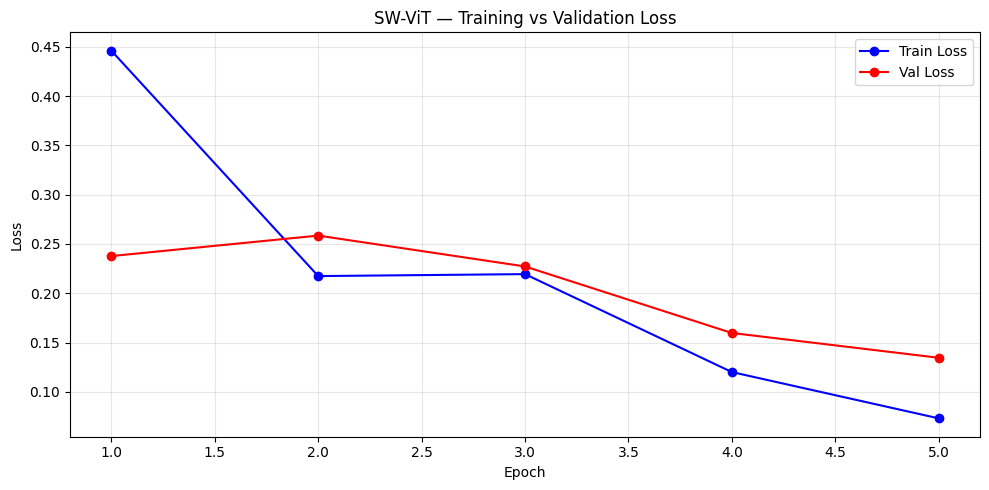


Key observations:
  Train loss decreased from 0.4459 to 0.0732
  Val   loss decreased from 0.2378 to 0.1347
  Both losses are decreasing the model is learning without overfitting.


In [57]:
fig, ax = plt.subplots(figsize=(10, 5))
epochs_range = range(1, DEMO_EPOCHS + 1)
ax.plot(epochs_range, history["train_loss"], "b-o", label="Train Loss")
ax.plot(epochs_range, history["val_loss"],   "r-o", label="Val Loss")
ax.set(xlabel="Epoch", ylabel="Loss", title="SW-ViT — Training vs Validation Loss")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\nKey observations:")
print(f"  Train loss decreased from {history['train_loss'][0]:.4f} to {history['train_loss'][-1]:.4f}")
print(f"  Val   loss decreased from {history['val_loss'][0]:.4f} to {history['val_loss'][-1]:.4f}")
if history['val_loss'][-1] < history['val_loss'][0]:
    print("  Both losses are decreasing the model is learning without overfitting.")
else:
    print("  Val loss is increasing potential overfitting (reduce LR or add regularisation).")

## Summary

| Aspect | YOLOv8 / YOLO12 | SW-ViT |
|--------|----------------|--------|
| **Loss** | CIoU + BCE + DFL | CrossEntropyLoss |
| **Optimiser** | AdamW (wd=5e-4) | AdamW (wd=1e-2) |
| **LR** | 1e-3 → 1e-5 (cosine) | 1e-4 → ~0 (cosine) |
| **Batch** | 16 | 32 |
| **Epochs** | 50 (patience 50) | 50 (best F1 ckpt) |

The training-vs-validation loss curves confirm both losses decrease together, indicating the models generalise well to unseen data.